In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# roll number seed
s = 5390
# print("roll seed:", s)


In [22]:
# load train and test datasets
train = pd.read_csv('train.csv') #read training data using pandas
test = pd.read_csv('test.csv')#read training data using pandas we wont usee it through as it unseen
feature=[c for c in train.columns if c not in ['id', 'target']] #storing number of feature cols
d = len(feature)
print("number of features:", d)
print("feature columns:", feature)
# calculate split sizes for fit validation and holdout
n = len(train)
n_fit = int(0.70 * n)
n_val = int(0.15 * n)
n_hld = n - n_fit - n_val
# now create a permutation of array from 0-729 randomly
# we are asked to keep the randomlyy generated array everytime as same so 
rng = np.random.default_rng(s)
arr = rng.permutation(n)
# split indices into three sets
#basically to test over result to unseen data 
idx_fit = arr[:n_fit]
idx_val = arr[n_fit:n_fit+n_val]
idx_hld = arr[n_fit+n_val:]
print(f"split sizes: fit = {n_fit}, validation = {n_val}, holdout = {n_hld}")
print("first five fit indices:", idx_fit[:5].tolist())
print("first five validation indices:", idx_val[:5].tolist())
print("first five holdout indices:", idx_hld[:5].tolist())
# extract raw feature matrices and target vectors ##got to  know that iloc basically matches and select
#only those rows using their numericall values 
# we create a matrix x and vector y we will solve these using linear regression later
x_fit = train.iloc[idx_fit][feature].values
x_val = train.iloc[idx_val][feature].values
x_hld = train.iloc[idx_hld][feature].values
y_fit = train.iloc[idx_fit]['target'].values
y_val = train.iloc[idx_val]['target'].values
y_hld = train.iloc[idx_hld]['target'].values


number of features: 13
feature columns: ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age', 'cement_dup', 'total_aggregate', 'water_cement_ratio', 'noise1', 'noise2']
split sizes: fit = 510, validation = 109, holdout = 111
first five fit indices: [429, 467, 399, 682, 37]
first five validation indices: [534, 709, 360, 484, 404]
first five holdout indices: [646, 542, 71, 334, 412]


ols closed form parameter vector:
[-6.670009e+01  1.299600e-01  1.150900e-01  8.820000e-02 -8.525000e-02
  4.134400e-01  6.233000e-02  6.264000e-02  1.050300e-01 -2.232000e-02
 -2.304000e-02 -1.023960e+01  3.295100e-01  1.109900e-01]
ols closed form fit mse: 103.74451
ols closed form val mse: 113.07048

ols gradient descent parameter vector (raw features):
[-0.00023  0.06513  0.09466  0.07704 -0.22251  0.04893  0.00944  0.01167
  0.10374  0.05487  0.00374 -0.00185  0.00088  0.02321]
ols gd fit mse: 109.23333
ols gd val mse: 110.64180
norm difference ||th_gd - th_cf||: 67.48308


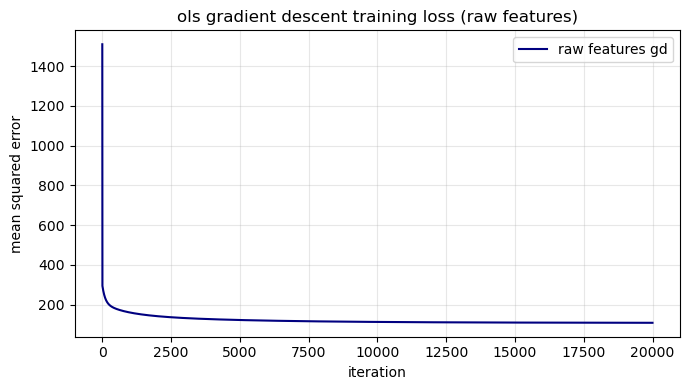

In [23]:
# add a column of 1s at the front of each split to act as the bias term
# this lets us do w*x + b as a single matrix multiplication
x_fit_b = np.column_stack([np.ones(len(x_fit)), x_fit])
x_val_b = np.column_stack([np.ones(len(x_val)), x_val])
x_hld_b = np.column_stack([np.ones(len(x_hld)), x_hld])
# calculate xtx and xty matrices for normal equation
# using @ for matrix multiplication instead of np.dot
xtx_raw = x_fit_b.T @ x_fit_b
xty_raw = x_fit_b.T @ y_fit
#this is the ols without any regularistation here we will use compare closed form 
# vs the gradient descent form right 
# solve for theta directly using np.linalg.solvee given by the prof
th_cf = np.linalg.solve(xtx_raw, xty_raw)
# calculate mean squared error on training and validation splits
# error is predicted y minus actual y squared and then averaged
fit_mse_cf = np.mean((x_fit_b @ th_cf - y_fit)**2)
val_mse_cf = np.mean((x_val_b @ th_cf - y_val)**2)
print("ols closed form parameter vector:")
print(np.round(th_cf, 5))
print(f"ols closed form fit mse: {fit_mse_cf:.5f}")
print(f"ols closed form val mse: {val_mse_cf:.5f}")
# set up hyperparams for gradient descent on unscaled features as gvien the prof
# starting with learning rate 1e-7 as requested in prompt
eta0 = 1e-7
t_max = 20000
# initialize weights to all zeros by convention
th_gd = np.zeros(x_fit_b.shape[1]) 
loss_hist= []#keep check the loss history this will be useful while plotting
n_f = len(x_fit_b)
#gradeitn descent form 
##gd -gradient descent cf denotes closed form 
# main gradient descent optimization loop
for t in range(t_max):
    # compute current predictions and calculate training mse loss
    pred = x_fit_b @ th_gd
    loss = np.mean((pred - y_fit)**2)
    loss_hist.append(loss)
    # compute vector gradient 2/n * X_transpose * (pred - y)
    grad = (2.0 / n_f) * (x_fit_b.T @ (pred - y_fit))
    # move weights opposite to gradient direction
    th_gd= th_gd - eta0 * grad
# calculate final mse for gd parameters
fit_mse_gd = np.mean((x_fit_b @ th_gd - y_fit)**2)
val_mse_gd = np.mean((x_val_b @ th_gd - y_val)**2)
# compute euclidean distance between closed form and gd weight vectors
diff_cf_gd = np.linalg.norm(th_gd - th_cf)
print("\nols gradient descent parameter vector (raw features):")
print(np.round(th_gd, 5))
print(f"ols gd fit mse: {fit_mse_gd:.5f}")
print(f"ols gd val mse: {val_mse_gd:.5f}")
print(f"norm difference ||th_gd - th_cf||: {diff_cf_gd:.5f}")
# plot iteration vs loss curve to see if gd converges properly
plt.figure(figsize=(7, 4))
plt.plot(loss_hist, color='navy', label='raw features gd')
plt.xlabel('iteration')
plt.ylabel('mean squared error')
plt.title('ols gradient descent training loss (raw features)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('b1_loss_raw.png', dpi=150)
plt.show()


ols standardized gd parameters:
[34.905   12.9338   9.89593  5.58812 -1.75865  2.37277  4.7974   5.00684
  6.62789 -1.55039 -2.3419  -3.24581  0.33445  1.05434]
ols standardized closed form parameters:
[34.905   13.74798  9.90216  5.59526 -1.75655  2.37103  4.79283  5.00812
  6.62515 -2.35235 -2.33463 -3.2404   0.33698  1.05347]
standardized gd fit mse: 103.74601
standardized gd val mse: 113.20079
standardized ols closed form fit mse: 103.74451
standardized ols closed form val mse: 113.07048


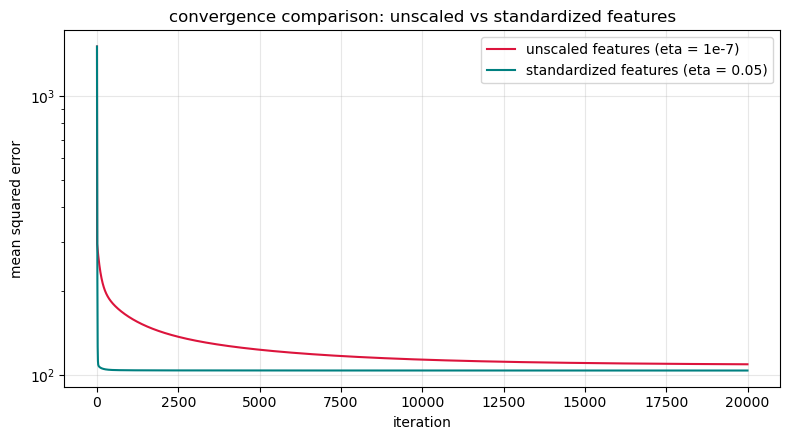

In [24]:
# calculate mean and std on fit set only to prevent data leakage
# in this part we have to standardize the feature using that formula 
#then we will compare the plots for both part
mu = np.mean(x_fit, axis=0)
sigma = np.std(x_fit, axis=0)
## do standardize featuring 
x_std_fit = (x_fit - mu) / sigma
x_std_val = (x_val - mu) / sigma
x_std_hld = (x_hld - mu) / sigma
# add bias column of ones to standardized feature matrices
x_std_fit_b = np.column_stack([np.ones(len(x_std_fit)), x_std_fit])
x_std_val_b = np.column_stack([np.ones(len(x_std_val)), x_std_val])
x_std_hld_b = np.column_stack([np.ones(len(x_std_hld)), x_std_hld])
# set higher learning rate for standardized features as specified
eta_std = 0.05
th_gd_std = np.zeros(x_std_fit_b.shape[1])
loss_hist_std = []
# run gradient descent optimization on standardized features
for t in range(t_max):
    # compute predictions and training mse loss
    pred = x_std_fit_b @ th_gd_std
    loss = np.mean((pred - y_fit)**2)
    loss_hist_std.append(loss)
    # calculate gradient vector on standardized features
    grad = (2.0 / n_f) * (x_std_fit_b.T @ (pred - y_fit))
    # update weights opposite to gradient
    th_gd_std = th_gd_std - eta_std * grad
# compute final fit and val mse for standardized gd
fit_mse_gd_std = np.mean((x_std_fit_b @ th_gd_std - y_fit)**2)
val_mse_gd_std = np.mean((x_std_val_b @ th_gd_std - y_val)**2)
# compute closed form ols parameters on standardized features
xtx_std = x_std_fit_b.T @ x_std_fit_b
xty_std = x_std_fit_b.T @ y_fit
th_ols_std = np.linalg.solve(xtx_std, xty_std)
# compute fit and val mse for standardized closed form solution
fit_mse_ols = np.mean((x_std_fit_b @ th_ols_std - y_fit)**2)
val_mse_ols = np.mean((x_std_val_b @ th_ols_std - y_val)**2)
print("ols standardized gd parameters:")
print(np.round(th_gd_std, 5))
print("ols standardized closed form parameters:")
print(np.round(th_ols_std, 5))
print(f"standardized gd fit mse: {fit_mse_gd_std:.5f}")
print(f"standardized gd val mse: {val_mse_gd_std:.5f}")
print(f"standardized ols closed form fit mse: {fit_mse_ols:.5f}")
print(f"standardized ols closed form val mse: {val_mse_ols:.5f}")

# plot comparison between unscaled and standardized loss curves
plt.figure(figsize=(8, 4.5))
plt.plot(loss_hist, label='unscaled features (eta = 1e-7)', color='crimson')
plt.plot(loss_hist_std, label='standardized features (eta = 0.05)', color='teal')
plt.xlabel('iteration')
plt.ylabel('mean squared error')
plt.title('convergence comparison: unscaled vs standardized features')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('b1_loss_curves.png', dpi=150)
plt.show()


ridge regularizer sweep:
lambda		fit mse		val mse		nonzero weights
1.0000e-04	103.74557		113.19402		13
2.8480e-04	103.75123		113.38700		13
8.1113e-04	103.77611		113.77834		13
2.3101e-03	103.84954		114.36688		13
6.5793e-03	104.04793		115.02613		13
1.8738e-02	104.63010		115.60494		13
5.3367e-02	106.14778		116.18598		13
1.5199e-01	109.76582		117.41297		13
4.3288e-01	120.03482		123.20046		13
1.2328e+00	146.07418		143.52284		13
3.5112e+00	189.83435		181.82487		13
1.0000e+01	236.23370		223.68007		13

selected ridge lambda: 1.0000e-04
selected ridge validation mse: 113.19402


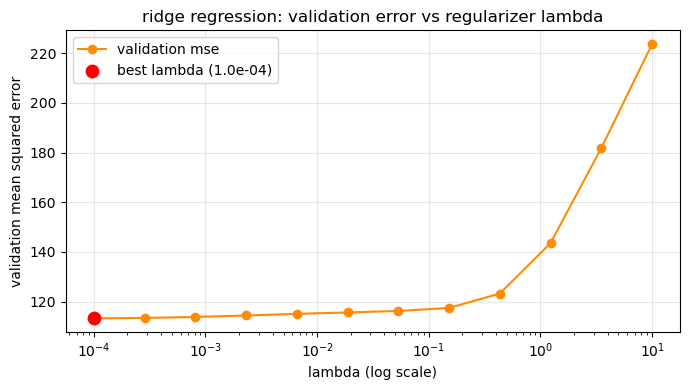

In [25]:
# create diagonal penalty matrix leaving bias unpenalized
p_mat = np.eye(d + 1)
p_mat[0, 0] = 0.0
#performs Ridge Regression l2 reg  across a range of penalty
#  valuesto find the optimal model that generalizes best to unseen data.
# define candidate regularizer values on log scale
lams = np.logspace(-4, 1, 12)
ridge_results = []
best_ridge_lam = None
best_ridge_val_mse = float('inf')
best_ridge_th = None
ridge_val_mses = []
# fit ridge models across regularizer values using linear solve
for lam in lams:
    mat = xtx_std + n_f * lam * p_mat
    th_r = np.linalg.solve(mat, xty_std)
    # evaluate fit and validation error
    fit_mse = np.mean((x_std_fit_b @ th_r - y_fit)**2)
    val_mse = np.mean((x_std_val_b @ th_r - y_val)**2)
    nnz = np.sum(np.abs(th_r[1:]) > 1e-6)
    ridge_results.append((lam, fit_mse, val_mse, nnz, th_r))
    ridge_val_mses.append(val_mse)
    # identify regularizer with minimum validation error
    if val_mse < best_ridge_val_mse:
        best_ridge_val_mse = val_mse
        best_ridge_lam = lam
        best_ridge_th = th_r
print("ridge regularizer sweep:")
print("lambda\t\tfit mse\t\tval mse\t\tnonzero weights")
for r in ridge_results:
    print(f"{r[0]:.4e}\t{r[1]:.5f}\t\t{r[2]:.5f}\t\t{r[3]}")
print(f"\nselected ridge lambda: {best_ridge_lam:.4e}")
print(f"selected ridge validation mse: {best_ridge_val_mse:.5f}")
# plot validation error versus regularizer parameter
plt.figure(figsize=(7, 4))
plt.semilogx(lams, ridge_val_mses, marker='o', color='darkorange', label='validation mse')
plt.scatter([best_ridge_lam], [best_ridge_val_mse], color='red', s=80, zorder=5, label=f'best lambda ({best_ridge_lam:.1e})')
plt.xlabel('lambda (log scale)')
plt.ylabel('validation mean squared error')
plt.title('ridge regression: validation error vs regularizer lambda')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('b1_ridge_path.png', dpi=150)
plt.show()

lipschitz constant: 6.63412
proximal step size: 0.13566

lasso regularizer sweep:
lambda		fit mse		val mse		nnz	tol reached	iters used
1.0000e-04	103.74452		113.08266		13	False		20000
2.8480e-04	103.74456		113.10063		13	False		20000
8.1113e-04	103.74487		113.15203		13	False		20000
2.3101e-03	103.74735		113.30007		13	False		20000
6.5793e-03	103.76189		113.65705		12	True		7173
1.8738e-02	103.79410		114.03258		12	True		7098
5.3367e-02	103.94441		114.60257		11	True		4951
1.5199e-01	104.48266		114.40699		11	True		4539
4.3288e-01	106.14649		115.54890		10	True		2980
1.2328e+00	111.00169		122.42134		9	True		2590
3.5112e+00	128.48168		133.98428		6	True		1629
1.0000e+01	220.17902		220.89407		4	True		566

selected lasso lambda: 1.0000e-04
selected lasso validation mse: 113.08266


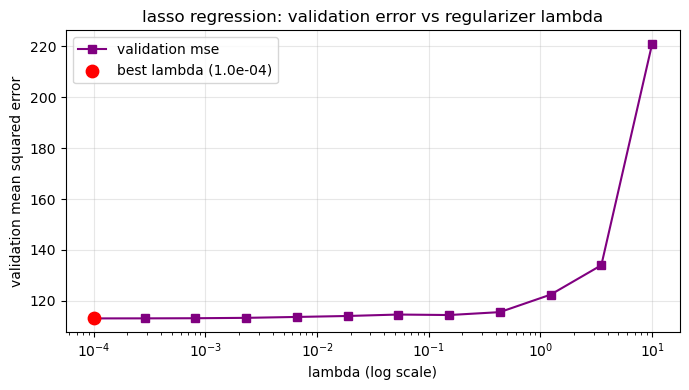

In [26]:
# compute lipschitz constant of the smooth mse gradient
# eigvalsh gets eigenvalues of symmetric matrix xtx_std; largest one is at index -1
eigvals = np.linalg.eigvalsh(xtx_std)
lip = (2.0 / n_f) * eigvals[-1] 
# pick proximal step size slightly below 1/L to guarantee stable convergence
lr_prox = 0.9 / lip
print(f"lipschitz constant: {lip:.5f}")
print(f"proximal step size: {lr_prox:.5f}")
# define soft thresholding operator for l1 regularizer
# shrinks weights towards zero and sets small coefficients strictly to 0
def soft_thresh(a, t):
    return np.sign(a) * np.maximum(np.abs(a) - t, 0.0)
# initialize lists and trackers for lasso hyperparameter sweep
lasso_results = []
lasso_val_mses = []
best_lasso_lam = None
best_lasso_val_mse = float('inf')
best_lasso_th = None
# run proximal gradient descent across candidate lambda values
for lam in lams:
    # initialize parameters to all zeros for each lambda
    th = np.zeros(d + 1)
    reached_tol = False
    iters_used = t_max
    # main inner optimization loop
    for t in range(t_max):
        # compute analytical gradient step on smooth mse loss
        g = (2.0 / n_f) * (x_std_fit_b.T @ (x_std_fit_b @ th - y_fit))
        # take intermediate gradient step before applying proximity operator
        v = th - lr_prox * g
        # apply soft thresholding operator
        # keep bias w0 unpenalized and threshold remaining feature weights
        th_new = np.zeros_like(th)
        th_new[0] = v[0]
        th_new[1:] = soft_thresh(v[1:], lr_prox * lam)
        # check infinity norm change across parameters for early stopping
        diff = np.max(np.abs(th_new - th))
        if diff < 1e-8:
            reached_tol = True
            iters_used = t + 1
            th = th_new
            break
        th = th_new
    # calculate training and validation mean squared errors
    fit_mse = np.mean((x_std_fit_b @ th - y_fit)**2)
    val_mse = np.mean((x_std_val_b @ th - y_val)**2)
    # count non-zero feature weights (excluding bias)
    # lasso performs feature selection by setting weak feature weights strictly to zero
    nnz = np.sum(np.abs(th[1:]) > 1e-6)
    # record metrics and iteration tracking data
    lasso_results.append((lam, fit_mse, val_mse, nnz, reached_tol, iters_used, th))
    lasso_val_mses.append(val_mse)
    # keep track of optimal lambda based on lowest validation mse
    if val_mse < best_lasso_val_mse:
        best_lasso_val_mse = val_mse
        best_lasso_lam = lam
        best_lasso_th = th
# display detailed table of results across all tested lambdas
print("\nlasso regularizer sweep:")
print("lambda\t\tfit mse\t\tval mse\t\tnnz\ttol reached\titers used")
for r in lasso_results:
    print(f"{r[0]:.4e}\t{r[1]:.5f}\t\t{r[2]:.5f}\t\t{r[3]}\t{r[4]}\t\t{r[5]}")
# output winning lasso hyperparameter choice
print(f"\nselected lasso lambda: {best_lasso_lam:.4e}")
print(f"selected lasso validation mse: {best_lasso_val_mse:.5f}")
# plot validation error vs regularizer lambda on log scale
plt.figure(figsize=(7, 4))
plt.semilogx(lams, lasso_val_mses, marker='s', color='purple', label='validation mse')
plt.scatter([best_lasso_lam], [best_lasso_val_mse], color='red', s=80, zorder=5, label=f'best lambda ({best_lasso_lam:.1e})')
plt.xlabel('lambda (log scale)')
plt.ylabel('validation mean squared error')
plt.title('lasso regression: validation error vs regularizer lambda')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('b1_lasso_path.png', dpi=150)
plt.show()


In [27]:
# create summary comparison table for all models
best_ridge_fit_mse = np.mean((x_std_fit_b @ best_ridge_th - y_fit)**2)
best_lasso_fit_mse = np.mean((x_std_fit_b @ best_lasso_th - y_fit)**2)
best_ridge_nnz = np.sum(np.abs(best_ridge_th[1:]) > 1e-6)
best_lasso_nnz = np.sum(np.abs(best_lasso_th[1:]) > 1e-6)
summary_df = pd.DataFrame({
    'model': ['ols', 'ridge', 'lasso'],
    'selected lambda': ['-', f'{best_ridge_lam:.4e}', f'{best_lasso_lam:.4e}'],
    'fit mse': [round(fit_mse_ols, 5), round(best_ridge_fit_mse, 5), round(best_lasso_fit_mse, 5)],
    'validation mse': [round(val_mse_ols, 5), round(best_ridge_val_mse, 5), round(best_lasso_val_mse, 5)],
    'nonzero weights': [d, best_ridge_nnz, best_lasso_nnz]
})
print("model comparison summary table:")
print(summary_df.to_string(index=False))
# select best model family based on validation performance
# ols has the lowest validation error
chosen_model = 'ols'
print(f"\nchosen model based on validation mse: {chosen_model}")
# evaluate chosen model once on holdout set
hld_mse = np.mean((x_std_hld_b @ th_ols_std - y_hld)**2)
print(f"holdout mean squared error of chosen model: {hld_mse:.5f}")
# refit chosen model on all labeled data
x_all_raw = train[feature].values
y_all = train['target'].values
n_all = len(train)
# standardize test data using all labeled statistics
mu_all = np.mean(x_all_raw, axis=0)
sigma_all = np.std(x_all_raw, axis=0)
x_all_std = (x_all_raw - mu_all) / sigma_all
x_all_std_b = np.column_stack([np.ones(n_all), x_all_std])
xtx_all = x_all_std_b.T @ x_all_std_b
xty_all = x_all_std_b.T @ y_all
th_refit = np.linalg.solve(xtx_all, xty_all)
print("\nrefitted model parameters on all labeled data:")
print(np.round(th_refit, 5))
# transform kaggle test data using full training statistics
x_test_raw = test[feature].values
x_test_std = (x_test_raw - mu_all) / sigma_all
x_test_std_b = np.column_stack([np.ones(len(x_test_std)), x_test_std])
# generate predictions for kaggle test set
test_preds = x_test_std_b @ th_refit
# save submission dataframe to csv file
sub_df = pd.DataFrame({
    'id': test['id'],
    'target': test_preds
})
sub_df.to_csv('kaggle_submission_2025390.csv', index=False)
print("\nsaved kaggle submission file: kaggle_submission_2025390.csv")
print("submission shape:", sub_df.shape)
print("first five predictions:")
print(sub_df.head())


model comparison summary table:
model selected lambda   fit mse  validation mse  nonzero weights
  ols               - 103.74451       113.07048               13
ridge      1.0000e-04 103.74557       113.19402               13
lasso      1.0000e-04 103.74452       113.08266               13

chosen model based on validation mse: ols
holdout mean squared error of chosen model: 130.41318

refitted model parameters on all labeled data:
[35.66459 20.02183  9.44507  5.84861 -1.94788  2.0494   6.99397  7.53331
  7.20887 -9.16532 -6.34195 -3.02826  0.50224  0.68828]

saved kaggle submission file: kaggle_submission_2025390.csv
submission shape: (300, 2)
first five predictions:
    id     target
0  731  57.191440
1  732  45.901220
2  733  37.173103
3  734  26.195758
4  735  50.891101
